# Brock-Mirman with Endogenous Labor — DEQN-JAX

Second in the `examples/` series (see `bm_deterministic.ipynb` first). Based on Azinovic, Gaegauf & Scheidegger (2022): stochastic Brock-Mirman augmented with an endogenous labor-supply choice.

## Model

Extends the stochastic Brock-Mirman by adding an endogenous labor-supply choice. The representative agent maximises
$$\max\; E\sum_t \beta^t \Bigl[\ln C_t - \psi\,\tfrac{L_t^{1+\theta}}{1+\theta}\Bigr]$$
subject to $K_{t+1} + C_t = Y_t + (1-\delta) K_t$ with Cobb-Douglas production
$$Y_t = z_t\, L_t^{1-\alpha}\, K_t^{\alpha}, \qquad \ln z_{t+1} = \rho \ln z_t + \sigma\,\varepsilon_t.$$

- **State:** $(k, z)$ — capital and log-TFP
- **Policy:** $(s, L)$ — savings rate and labor supply
- **Equations:**
  1. Capital Euler: $u'(C_t) = \beta\, E[u'(C_{t+1}) (1-\delta + r_{t+1})]$
  2. Labor FOC (intratemporal): $w_t\, u'(C_t) = \psi\, L_t^\theta$

## What's new vs. Notebook 1

- A **second policy output** for $L$. The network uses a **softplus** output on that dimension (upper bound set to $\infty$ in `POLICY_UPPER`) to guarantee $L>0$.
- A **second equation** in the loss. Two residuals are averaged together by default; the trainer supports per-equation loss reweighting (`lr_annealing`, `relobralo`) when that's needed.
- An **expectation operator** under stochastic TFP. The trainer uses antithetic Monte Carlo shocks (`mc_samples`) to evaluate $E[\cdot]$ inside the Euler residual.

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import NetworkConfig, OptimizerConfig, TrainConfig
from deqn_jax.models.bm_labor import MODEL, steady_state
from deqn_jax.plots import plot_loss_curve, plot_per_equation_residuals
from deqn_jax.training.trainer import train_from_config

## 1. Inspect the model

In [2]:
print(f"Model:        {MODEL.name}")
print(f"States:       {MODEL.state_names}")
print(f"Policies:     {MODEL.policy_names}")
print(f"Equations:    {MODEL.equation_names}")
print(f"Shocks:       {MODEL.shock_names}  (n_shocks={MODEL.n_shocks})")
print("Bounds:")
print(f"  lower:      {MODEL.policy_lower}")
print(f"  upper:      {MODEL.policy_upper}   # inf on L => softplus output")
print()
for k, v in MODEL.constants.items():
    print(f"  {k:8s} = {v}")

Model:        bm_labor
States:       ('k', 'z')
Policies:     ('sav_rate', 'L')
Equations:    ('euler', 'labor_foc')
Shocks:       ('eps_z',)  (n_shocks=1)
Bounds:
  lower:      [1.e-06 1.e-06]
  upper:      [0.999999      inf]   # inf on L => softplus output

  alpha    = 0.36
  beta     = 0.99
  gamma    = 1.0
  delta    = 0.1
  rho_z    = 0.9
  sigma_z  = 0.04
  psi      = 1.0
  theta    = 1.0


## 2. Deterministic steady state

With $z=0$ the model has a closed-form steady state. Define $\kappa = k/L$ and use the Euler FOC:
$$\kappa^{1-\alpha} = \frac{\alpha\beta}{1 - \beta(1-\delta)}, \qquad L^{\gamma+\theta} = \frac{(1-\alpha)\,\kappa^\alpha}{\psi\,(\kappa^\alpha - \delta\kappa)^\gamma}.$$

We can verify the steady state is a fixed point of the model's dynamics (both residuals vanish, `step(ss) = ss`). This is a useful sanity check any time you hand-code a new model.

In [3]:
from deqn_jax.models.bm_labor.dynamics import step
from deqn_jax.models.bm_labor.equations import definitions, equations

C = MODEL.constants
ss_state, ss_policy = steady_state(C)
k_ss, z_ss = float(ss_state[0]), float(ss_state[1])
sav_ss, L_ss = float(ss_policy[0]), float(ss_policy[1])

print(f"k_ss         = {k_ss:.4f}")
print(f"L_ss         = {L_ss:.4f}")
print(f"sav_rate_ss  = {sav_ss:.4f}")

state = ss_state[None, :]
policy = ss_policy[None, :]
defs = definitions(state, policy, C)
print()
print(f"y_ss         = {float(defs['y'][0]):.4f}")
print(f"c_ss         = {float(defs['c'][0]):.4f}")
print(f"r_ss (mpk)   = {float(defs['mpk'][0]):.4f}")
print(f"w_ss         = {float(defs['w'][0]):.4f}")

# Fixed-point check
resids = equations(state, policy, state, policy, C)
next_state = step(state, policy, jnp.zeros((1, 1)), C)
print()
print(
    f"Residuals at SS:  euler={float(resids['euler'][0]):.2e}, labor_foc={float(resids['labor_foc'][0]):.2e}"
)
print(f"step(ss) - ss  :  {float(jnp.max(jnp.abs(next_state[0] - ss_state))):.2e}")

k_ss         = 6.2087
L_ss         = 0.9752
sav_rate_ss  = 0.3270

y_ss         = 1.8988
c_ss         = 1.2780
r_ss (mpk)   = 0.1101
w_ss         = 1.2462

Residuals at SS:  euler=5.96e-08, labor_foc=5.96e-08
step(ss) - ss  :  0.00e+00


## 3. Train

We build a `TrainConfig` and call `train_from_config`. That's the modern entry point; it uses a rollout-then-minibatch-sweep schedule that typically reaches $\sim 10^{-5}$ loss in ~500 episodes.

In [4]:
cfg = TrainConfig(
    model="bm_labor",
    episodes=500,
    batch_size=64,
    episode_length=100,
    mc_samples=5,
    network=NetworkConfig(hidden_sizes=(64, 64), activation="tanh"),
    optimizer=OptimizerConfig(name="adam", learning_rate=3e-4),
    warm_start=True,
    seed=0,
    verbose=False,
)

policy_net, history = train_from_config(cfg)

print(f"Initial loss: {history['loss'][0]:.3e}")
print(f"Final   loss: {history['loss'][-1]:.3e}")
# Per-equation residuals on the last episode
print()
for k in ["euler", "labor_foc"]:
    if k in history:
        print(f"  {k:12s} final: {history[k][-1]:.3e}")

Initial loss: 1.357e-01
Final   loss: 5.539e-06



## 4. Loss curves

Two panels: aggregate loss (mean of squared residuals) and per-equation residuals. It's worth checking that both equations decay together — if one dominates, reweighting may help.

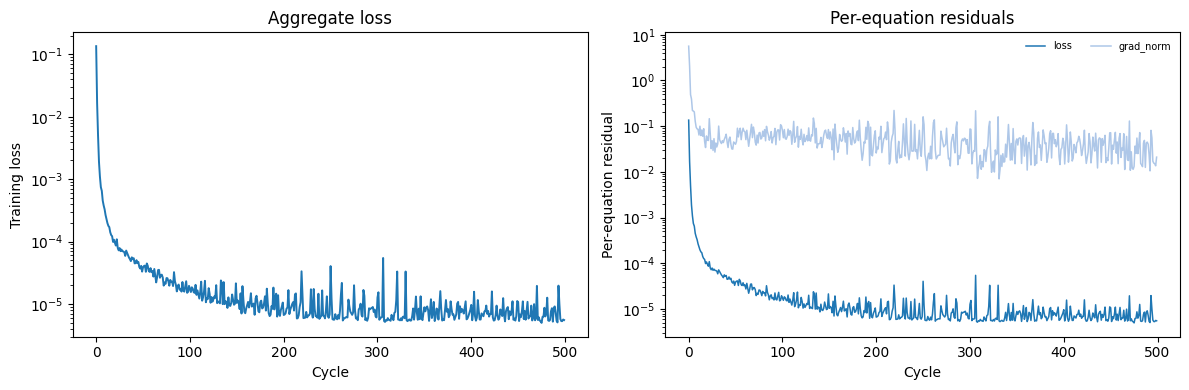

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_loss_curve(history, ax=axes[0])
axes[0].set_title("Aggregate loss")
plot_per_equation_residuals(history, ax=axes[1])
axes[1].set_title("Per-equation residuals")
plt.tight_layout()
plt.show()

## 5. Policy at the steady state

A converged DEQN should reproduce the analytic steady-state policy $(s^*, L^*)$ when evaluated at $(k_{ss}, z=0)$.

In [6]:
pred = np.asarray(policy_net(ss_state[None, :]))[0]
print("              pred         ss       rel. error")
print(
    f"  sav_rate    {pred[0]:.4f}      {sav_ss:.4f}   {abs(pred[0] - sav_ss) / sav_ss:.2%}"
)
print(f"  L           {pred[1]:.4f}      {L_ss:.4f}   {abs(pred[1] - L_ss) / L_ss:.2%}")

              pred         ss       rel. error
  sav_rate    0.3279      0.3270   0.27%
  L           0.9759      0.9752   0.08%


## 6. Policy functions over a state grid

Unlike the deterministic model in Notebook 1, the optimal policy here *does* depend on both states. Plot $s(k, z)$ and $L(k, z)$ on a grid to see the shape.

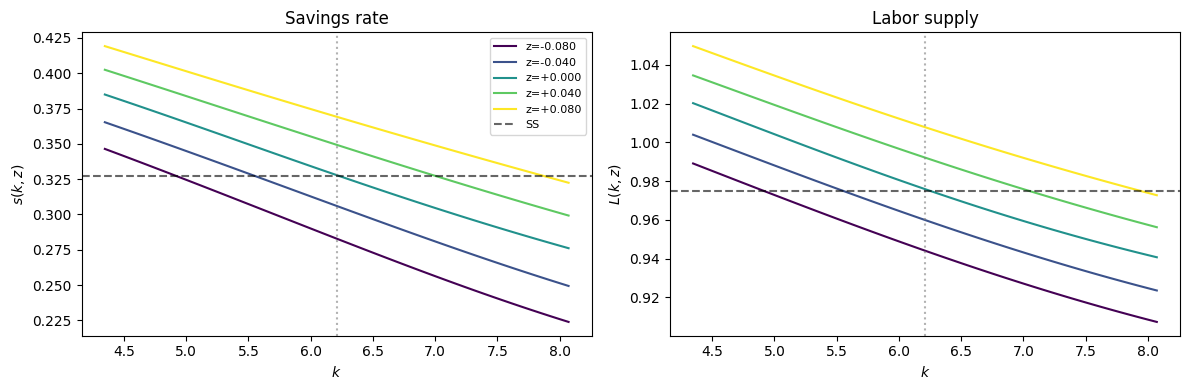

In [7]:
k_vals = np.linspace(0.7 * k_ss, 1.3 * k_ss, 50)
z_vals = np.linspace(-2 * C["sigma_z"], 2 * C["sigma_z"], 5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cmap = plt.cm.viridis(np.linspace(0, 1, len(z_vals)))
for z, col in zip(z_vals, cmap):
    grid = jnp.stack(
        [jnp.asarray(k_vals), jnp.full_like(jnp.asarray(k_vals), z)], axis=1
    )
    p = np.asarray(policy_net(grid))
    axes[0].plot(k_vals, p[:, 0], color=col, label=f"z={z:+.3f}")
    axes[1].plot(k_vals, p[:, 1], color=col)

axes[0].axvline(k_ss, color="grey", ls=":", alpha=0.6)
axes[0].axhline(sav_ss, color="k", ls="--", alpha=0.6, label="SS")
axes[0].set_xlabel("$k$")
axes[0].set_ylabel("$s(k, z)$")
axes[0].set_title("Savings rate")
axes[0].legend(fontsize=8)

axes[1].axvline(k_ss, color="grey", ls=":", alpha=0.6)
axes[1].axhline(L_ss, color="k", ls="--", alpha=0.6)
axes[1].set_xlabel("$k$")
axes[1].set_ylabel("$L(k, z)$")
axes[1].set_title("Labor supply")

plt.tight_layout()
plt.show()

## 7. Impulse response to a TFP shock

Use the framework's IRF tool (deterministic simulation starting from steady state with a one-off shock to $\varepsilon_z$).

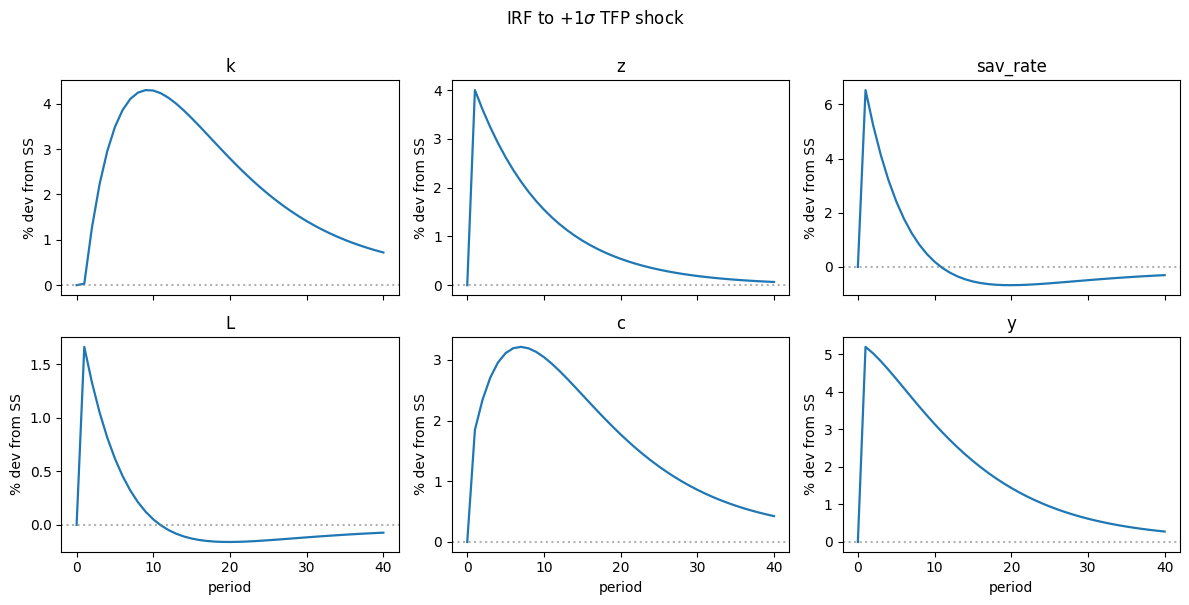

In [8]:
from deqn_jax.irf import run_irf

irf = run_irf(policy_net, MODEL, shock_name="eps_z", shock_size=1.0, horizon=40)

variables = ["k", "z", "sav_rate", "L", "c", "y"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
t = np.asarray(irf["period"])
for ax, var in zip(axes.flat, variables):
    series = np.asarray(irf[var])
    base = series[0] if abs(series[0]) > 1e-10 else 1.0
    pct = 100.0 * (series - series[0]) / abs(base)
    ax.plot(t, pct, lw=1.6)
    ax.axhline(0, color="grey", ls=":", alpha=0.6)
    ax.set_title(var)
    ax.set_ylabel("% dev from SS")
for ax in axes[-1]:
    ax.set_xlabel("period")
plt.suptitle("IRF to +1$\\sigma$ TFP shock", y=1.00)
plt.tight_layout()
plt.show()

## 8. Summary

- Added one policy output (softplus on $L$) and one equation (labor FOC) on top of the stochastic Brock-Mirman template.
- Loss reaches $\sim 10^{-5}$ in 500 episodes with the default rollout+minibatch-sweep schedule; both equations converge together.
- Policy at $(k_{ss}, 0)$ matches the closed-form steady state to sub-1 percent.
- IRF shows the textbook response: positive TFP persistently raises output, consumption, labor, and capital, with $z$ itself mean-reverting at rate $\rho$.

**Next notebook** (`olg_analytic_6.ipynb`): jump from representative-agent to a 6-generation OLG with log utility — 5 Euler equations, closed-form savings rates $\beta_h$ from Krueger & Kubler (2004).

### References
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525
